Проект для стажировки в Т-Банк


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

#----------------------Считываем данные----------------------
excel_file = pd.ExcelFile('data.xlsx')
df_users = pd.read_excel(excel_file, sheet_name='Пользователи')
df_payments = pd.read_excel(excel_file, sheet_name='Платежи')

 #----------------------Делаем нужный формат----------------------
date_cols = ['step1_opened', 'step2_entered', 'step3_confirmed', 'step4_success']
for col in date_cols:
    df_payments[col] = pd.to_datetime(df_payments[col], errors='coerce')

#----------------------поработаем с некорректными записями----------------------
df = df = df_payments.merge(
    df_users[['user_id', 'group','age', 'city', 'device_type']],
    on=['user_id', 'group'],
    how='left'
)
df = df[df['group'].notna()]
df = df[(df['age'] < 100) & (df['age'] >= 18)]
df = df[df['user_id'].notna()]
df = df[df['step1_opened'].notna()]

#----------------------Проведем анализ на всех данных----------------------
df_A = df[df['group'] == 'A']
df_B = df[df['group'] == 'B']
n_A = df_A['user_id'].nunique()
n_B = df_B['user_id'].nunique()
k_A = df_A[df_A['step4_success'].notna()]['user_id'].nunique()
k_B = df_B[df_B['step4_success'].notna()]['user_id'].nunique()
print('k_A =', k_A,'k_B =', k_B, 'n_A =', n_A,'n_B =', n_B)
p_value = ztest(k_A,k_B, n_A, n_B)
print('p-value =', p_value)

k_A = 493 k_B = 603 n_A = 751 n_B = 750
p-value = 6.010086743268129e-11


In [115]:
#----------------------Проведем анализ только для владельцев android----------------------
k_A_android, k_B_android, n_A_android, n_B_android, p_value_android = analyze_segment(df, 'device_type', 'android')
print('k_A =', k_A_android,'k_B =', k_B_android, 'n_A =', n_A_android,'n_B =', n_B_android)
print('p-value =', p_value_android)

k_A = 262 k_B = 295 n_A = 407 n_B = 369
p-value = 7.421918999928546e-07


In [116]:
#----------------------Проведем анализ только для владельцев ios----------------------
k_A_ios, k_B_ios, n_A_ios, n_B_ios, p_value_ios = analyze_segment(df, 'device_type', 'ios')
print('k_A =', k_A_ios,'k_B =', k_B_ios, 'n_A =', n_A_ios,'n_B =', n_B_ios)
print('p-value =', p_value_ios)

k_A = 231 k_B = 308 n_A = 344 n_B = 381
p-value = 1.2528975680756285e-05


In [117]:
#----------------------Проведем анализ только для жителей Москвы----------------------
k_A_msk, k_B_msk, n_A_msk, n_B_msk, p_value_msk = analyze_segment(df, 'city', 'Москва')
print('k_A =', k_A_msk,'k_B =', k_B_msk, 'n_A =', n_A_msk,'n_B =', n_B_msk)
print('p-value =', p_value_msk)

k_A = 180 k_B = 248 n_A = 288 n_B = 306
p-value = 2.4009523126241313e-07


In [118]:
#----------------------Проведем анализ только для жителей СПб----------------------
k_A_spb, k_B_spb, n_A_spb, n_B_spb, p_value_spb = analyze_segment(df, 'city', 'СПб')
print('k_A =', k_A_spb,'k_B =', k_B_spb, 'n_A =', n_A_spb,'n_B =', n_B_spb)
print('p-value =', p_value_spb)

k_A = 133 k_B = 168 n_A = 194 n_B = 199
p-value = 0.0001021565781592937


In [119]:
#----------------------Проведем анализ только для жителей Региона----------------------
k_A_reg, k_B_reg, n_A_reg, n_B_reg, p_value_reg = analyze_segment(df, 'city', 'Регион')
print('k_A =', k_A_reg,'k_B =', k_B_reg, 'n_A =', n_A_reg,'n_B =', n_B_reg)
print('p-value =', p_value_reg)

k_A = 179 k_B = 187 n_A = 268 n_B = 245
p-value = 0.00851862794405774


Вспомогательные функции

In [ ]:
def ztest(k_A, k_B, n_A, n_B):
    p_hat_A = k_A / n_A
    p_hat_B = k_B / n_B
    p_pooled = (k_A + k_B) / (n_A + n_B)
    SE = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_A + 1/n_B))
    Z = (p_hat_A - p_hat_B) / SE
    p_value = stats.norm.cdf(Z)
    return p_value

In [114]:
def analyze_segment(df, segment_col, segment_value):
    df_seg = df[df[segment_col] == segment_value]
    df_A = df_seg[df_seg['group'] == 'A']
    df_B = df_seg[df_seg['group'] == 'B']
    
    n_A = df_A['user_id'].nunique()
    n_B = df_B['user_id'].nunique()
    k_A = df_A[df_A['step4_success'].notna()]['user_id'].nunique()
    k_B = df_B[df_B['step4_success'].notna()]['user_id'].nunique()
    
    p_value = ztest(k_A, k_B, n_A, n_B)
    
    return k_A, k_B, n_A, n_B, p_value

Построим графики

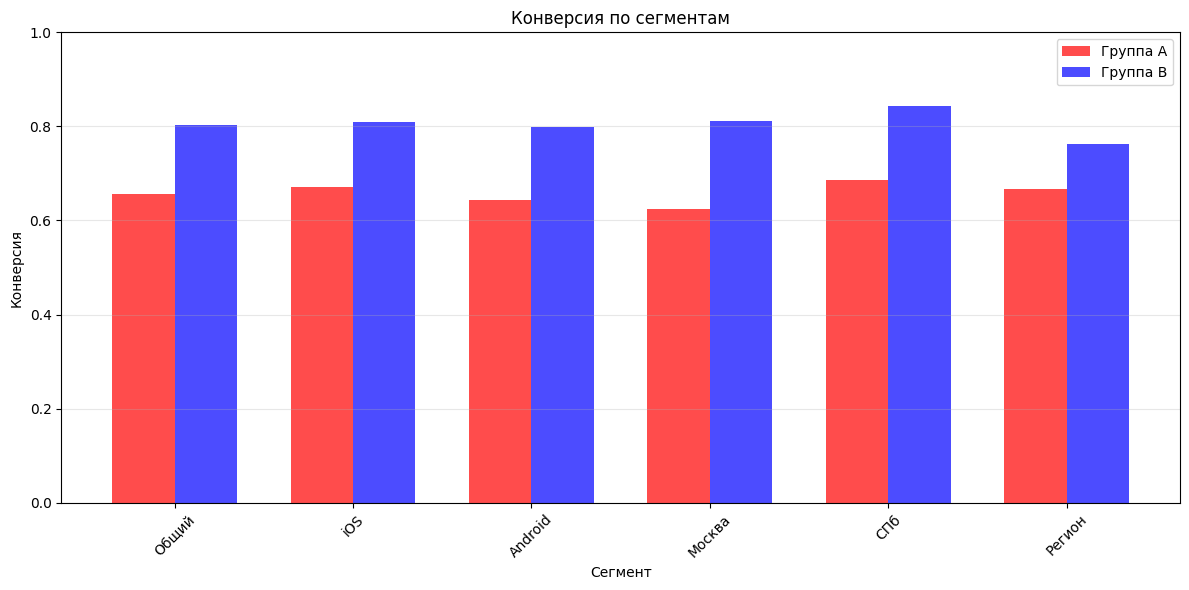

In [124]:
import matplotlib.pyplot as plt
import numpy as np

segments = ['Общий', 'iOS', 'Android', 'Москва', 'СПб', 'Регион']
conv_A = [k_A/n_A, k_A_ios/n_A_ios, k_A_android/n_A_android, 
          k_A_msk/n_A_msk, k_A_spb/n_A_spb, k_A_reg/n_A_reg]
conv_B = [k_B/n_B, k_B_ios/n_B_ios, k_B_android/n_B_android,
          k_B_msk/n_B_msk, k_B_spb/n_B_spb, k_B_reg/n_B_reg]

x = np.arange(len(segments))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, conv_A, width, label='Группа A', color='red', alpha=0.7)
bars2 = ax.bar(x + width/2, conv_B, width, label='Группа B', color='blue', alpha=0.7)

ax.set_xlabel('Сегмент')
ax.set_ylabel('Конверсия')
ax.set_title('Конверсия по сегментам')
ax.set_xticks(x)
ax.set_xticklabels(segments, rotation=45)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#----------------------Проведем анализ только для жителей Региона----------------------
k_A_reg, k_B_reg, n_A_reg, n_B_reg, p_value_reg = analyze_segment(df, 'city', 'Регион')
print('k_A =', k_A_reg,'k_B =', k_B_reg, 'n_A =', n_A_reg,'n_B =', n_B_reg)
print('p-value =', p_value_reg)

k_A = 179 k_B = 187 n_A = 268 n_B = 245
p-value = 0.00851862794405774


Итоговая сводная таблица

In [120]:
results = pd.DataFrame({
    'Сегмент': ['Общий', 'iOS', 'Android', 'Москва', 'СПб', 'Регион'],
    'Конверсия A': [k_A/n_A, k_A_ios/n_A_ios, k_A_android/n_A_android,
                    k_A_msk/n_A_msk, k_A_spb/n_A_spb, k_A_reg/n_A_reg],
    'Конверсия B': [k_B/n_B, k_B_ios/n_B_ios, k_B_android/n_B_android,
                    k_B_msk/n_B_msk, k_B_spb/n_B_spb, k_B_reg/n_B_reg],
    'p-value': [p_value, p_value_ios, p_value_android,
                p_value_msk, p_value_spb, p_value_reg]
})

results['Прирост'] = results['Конверсия B'] - results['Конверсия A']
results['Значимо'] = results['p-value'] < 0.05

print(results.to_string(index=False))

Сегмент  Конверсия A  Конверсия B      p-value  Прирост  Значимо
  Общий     0.656458     0.804000 6.010087e-11 0.147542     True
    iOS     0.671512     0.808399 1.252898e-05 0.136887     True
Android     0.643735     0.799458 7.421919e-07 0.155723     True
 Москва     0.625000     0.810458 2.400952e-07 0.185458     True
    СПб     0.685567     0.844221 1.021566e-04 0.158654     True
 Регион     0.667910     0.763265 8.518628e-03 0.095355     True
